# 01. Historical extraction: Banco de Portugal / INE

Extract the 1977-1995 balance, account, transfer and macro tables directly from the bundled official long-series workbook, and check that the extracted accounts satisfy revenue minus expenditure equals the balance.

**Reads**

- `data/raw/banco_portugal/series_longas_2023-12.xlsx`

**Writes**

- `data/interim/historical_balances_1977_1995.csv`
- `data/interim/historical_accounts_1977_1995.csv`
- `data/interim/historical_intragov_transfers_1977_1995.csv`
- `data/interim/historical_macro_1977_1995.csv`

**Method reference:** `METHODOLOGY.md` sections 3-4

In [1]:
"""Notebook environment: locate the repository and expose its data layers."""

import sys
import warnings
from pathlib import Path

import pandas as pd
from IPython.display import display

# Resolve the repository root from wherever the kernel was started, so the
# notebook works both from the repository root and from the notebooks directory.
ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

%matplotlib inline

from portugal_fiscal_balance.analysis import figures

RAW = ROOT / 'data' / 'raw'
INTERIM = ROOT / 'data' / 'interim'
PROCESSED = ROOT / 'data' / 'processed'
TABLES = ROOT / 'outputs' / 'tables'
METRICS = ROOT / 'outputs' / 'metrics'

warnings.filterwarnings('ignore', category=UserWarning, module='openpyxl')
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 200)

print('repository:', ROOT.name)
print('pipeline outputs present:', (PROCESSED / 'fiscal_balances_1977_2025.csv').exists())

repository: portugal-fiscal-balance
pipeline outputs present: True


## 1. Parse the workbook

The historical workbook holds sector accounts, B.9 balances, intragovernmental
transfers, GDP and labour-market series across several sheets and layouts. The
parser lives in `portugal_fiscal_balance.sources.banco_portugal`, so the parsing
rules are testable and this notebook stays a narrative.

In [2]:
from portugal_fiscal_balance.io import write_csv
from portugal_fiscal_balance.sources.banco_portugal import extract_long_series

historical = extract_long_series(RAW / 'banco_portugal' / 'series_longas_2023-12.xlsx')
shapes = pd.DataFrame(
    [
        {'table': 'balances', 'rows': historical.balances.shape[0], 'columns': historical.balances.shape[1]},
        {'table': 'accounts', 'rows': historical.accounts.shape[0], 'columns': historical.accounts.shape[1]},
        {'table': 'transfers', 'rows': historical.transfers.shape[0], 'columns': historical.transfers.shape[1]},
        {'table': 'macro', 'rows': historical.macro.shape[0], 'columns': historical.macro.shape[1]},
    ]
)
display(shapes)

,table,rows,columns
0,balances,19,19
1,accounts,76,40
2,transfers,57,10
3,macro,19,9


## 2. The historical balance panel

The four balances are reported in millions of euro alongside nominal GDP, which
makes the GDP ratios reproducible rather than copied from a published table.

In [3]:
balance_columns = [
    'year',
    'general_government_balance_m_eur',
    'central_government_balance_m_eur',
    'regional_local_balance_m_eur',
    'social_security_balance_m_eur',
    'nominal_gdp_m_eur',
]
display(historical.balances[balance_columns].tail(8).round(1))

,year,general_government_balance_m_eur,central_government_balance_m_eur,regional_local_balance_m_eur,social_security_balance_m_eur,nominal_gdp_m_eur
11,1988,-1123.7,-1430.6,75.3,231.6,35416.4
12,1989,-890.9,-1112.7,-64.6,286.4,41841.3
13,1990,-2526.3,-2418.2,-336.1,228.0,50239.2
14,1991,-3455.1,-3255.2,-130.0,-69.9,57608.1
15,1992,-1908.3,-2029.3,-59.7,180.8,64765.9
16,1993,-4129.8,-4086.6,-269.7,226.5,67733.3
17,1994,-4456.9,-4071.8,-106.7,-278.4,73437.8
18,1995,-4557.7,-4220.7,32.6,-369.5,79373.1


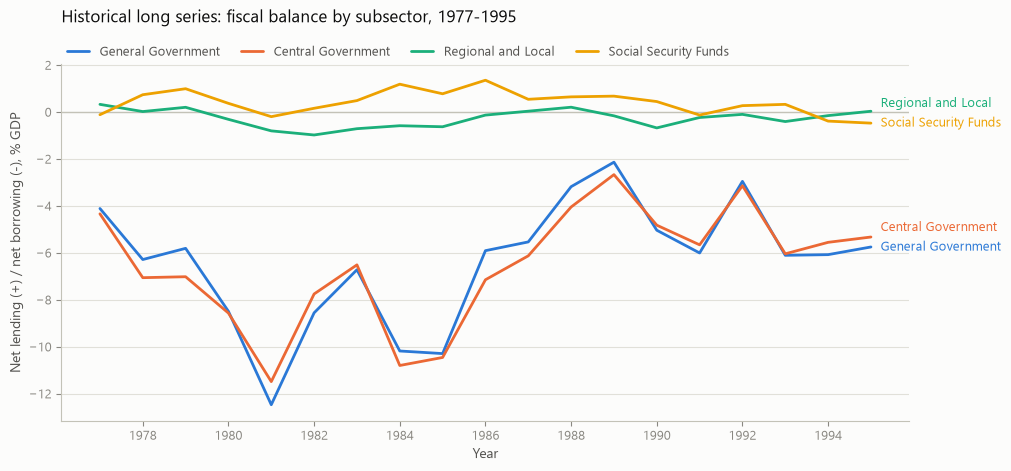

In [4]:
figure = figures.balances_by_subsector(
    historical.balances,
    title='Historical long series: fiscal balance by subsector, 1977-1995',
    splice_year=None,
)

The 1995 observation is extracted here but is **not** used in the canonical
panel: notebook 03 takes 1995 from the modern source and keeps this vintage only
as an overlap diagnostic.

## 3. Detailed subsector accounts

In [5]:
account_columns = [
    'year',
    'sector',
    'total_revenue_m_eur',
    'total_expenditure_m_eur',
    'interest_m_eur',
    'gfcf_m_eur',
    'balance_m_eur',
]
recent_accounts = historical.accounts.loc[historical.accounts['year'].ge(1993), account_columns]
display(recent_accounts.sort_values(['sector', 'year']).round(1))

,year,sector,total_revenue_m_eur,total_expenditure_m_eur,interest_m_eur,gfcf_m_eur,balance_m_eur
16,1993,central_government,17570.8,21657.4,3998.2,1392.2,-4086.6
17,1994,central_government,18654.6,22726.3,4366.0,1514.9,-4071.8
18,1995,central_government,20382.7,24603.4,4790.1,1771.1,-4220.7
35,1993,general_government,27547.1,31676.9,4164.8,2731.6,-4129.8
36,1994,general_government,28802.5,33259.4,4532.0,2687.0,-4456.9
37,1995,general_government,32009.1,36566.8,4975.1,3005.5,-4557.7
54,1993,regional_local_government,3419.1,3688.7,180.6,1337.9,-269.7
55,1994,regional_local_government,3468.9,3575.6,183.7,1165.2,-106.7
56,1995,regional_local_government,3827.1,3794.5,194.3,1225.4,32.6
73,1993,social_security_funds,9436.9,9210.4,7.4,1.5,226.5


## 4. Extraction check

If the parser mapped a row incorrectly, revenue minus expenditure would stop
reproducing the published balance. The residual below is therefore an extraction
test, not an economic result.

In [6]:
identity = (
    historical.accounts.groupby('sector')['account_identity_error_m_eur']
    .apply(lambda column: column.abs().max())
    .rename('max_abs_identity_error_m_eur')
    .to_frame()
)
display(identity)
print('worst absolute account identity error (M EUR):', float(identity.max().iloc[0]))

,max_abs_identity_error_m_eur
sector,
central_government,5.456968e-12
general_government,3.637979e-12
regional_local_government,2.842171e-13
social_security_funds,9.379164e-13


worst absolute account identity error (M EUR): 5.4569682106375694e-12


## 5. Transfers and macro context

The transfer table supports the mechanical sensitivity in notebook 10. The macro
table supplies the historical labour-market controls used in notebook 14.

In [7]:
display(historical.transfers.loc[historical.transfers['year'].ge(1993)].round(1))
display(historical.macro.tail(6).round(3))

,year,sector,intragov_current_received_m_eur,intragov_capital_received_m_eur,intragov_current_paid_m_eur,intragov_capital_paid_m_eur,intragov_received_m_eur,intragov_paid_m_eur,net_intragov_transfer_m_eur,source
16,1993,central_government,535.6,42.4,1646.9,579.4,578.0,2226.2,-1648.3,Banco de Portugal / INE long series
17,1994,central_government,453.9,36.6,1733.7,623.3,490.6,2357.0,-1866.4,Banco de Portugal / INE long series
18,1995,central_government,518.9,35.3,1510.9,680.8,554.2,2191.7,-1637.5,Banco de Portugal / INE long series
35,1993,regional_local_government,693.9,561.7,6.6,0.0,1255.5,6.7,1248.9,Banco de Portugal / INE long series
36,1994,regional_local_government,655.2,604.7,8.1,0.0,1259.9,8.1,1251.8,Banco de Portugal / INE long series
37,1995,regional_local_government,726.7,660.5,6.0,0.5,1387.2,6.5,1380.7,Banco de Portugal / INE long series
54,1993,social_security_funds,1007.0,17.7,582.9,42.3,1024.7,625.3,399.4,Banco de Portugal / INE long series
55,1994,social_security_funds,1090.5,18.6,457.8,36.6,1109.1,494.4,614.6,Banco de Portugal / INE long series
56,1995,social_security_funds,796.5,20.4,525.3,34.8,816.9,560.1,256.7,Banco de Portugal / INE long series


,year,population_k,labour_force_k,employment_k,employees_k,unemployment_k,unemployment_rate,source,nominal_gdp_m_eur
13,1990,10301.662,4593.174,4279.234,3301.659,313.941,0.068,Banco de Portugal / INE long series,50239.239
14,1991,10303.572,4628.945,4335.178,3314.886,293.767,0.063,Banco de Portugal / INE long series,57608.071
15,1992,10280.242,4600.618,4359.598,3327.618,241.020,0.052,Banco de Portugal / INE long series,64765.865
16,1993,10313.242,4599.747,4295.159,3243.876,304.587,0.066,Banco de Portugal / INE long series,67733.293
17,1994,10332.908,4664.898,4293.052,3175.445,371.846,0.080,Banco de Portugal / INE long series,73437.833
18,1995,10341.153,4708.370,4315.418,3164.019,392.952,0.083,Banco de Portugal / INE long series,79373.075


## 6. Persist the extraction

Extracted tables are written to `data/interim` under their source name. Keeping
extraction output separate from processed panels makes it possible to attribute a
later disagreement to a specific source.

In [8]:
write_csv(historical.balances, INTERIM / 'historical_balances_1977_1995.csv')
write_csv(historical.accounts, INTERIM / 'historical_accounts_1977_1995.csv')
write_csv(historical.transfers, INTERIM / 'historical_intragov_transfers_1977_1995.csv')
write_csv(historical.macro, INTERIM / 'historical_macro_1977_1995.csv')
print('written to', INTERIM.relative_to(ROOT))

written to data\interim


## Interpretation limits

1. These are **historical-vintage** national accounts. They are not directly
   comparable with post-1995 ESA 2010 figures, and this repository never
   calibrates one to the other.
2. The workbook is a **secondary compilation** of historical statistics. Its own
   revisions are outside the scope of this repository.
3. Labour-market series from this period are used only as descriptive controls in
   notebook 14.

---

[Previous: 00. Research protocol](00_research_protocol.ipynb) | [Next: 02. Modern extraction: INE/PORDATA and CFP](02_extract_modern_data.ipynb)

Every table shown above is also persisted as CSV, so results can be checked without reading notebook state. To rebuild everything from the bundled raw sources:

```bash
poetry install
make all
```